Features: (150, 2), Labels: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


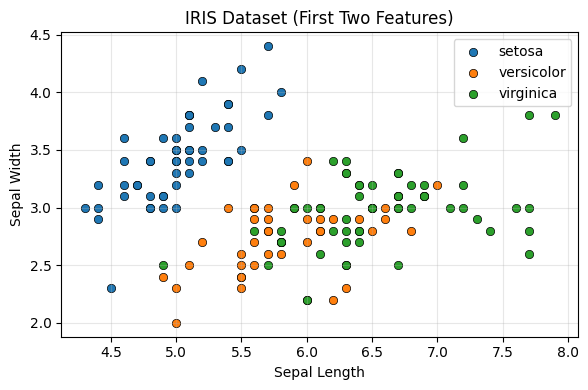

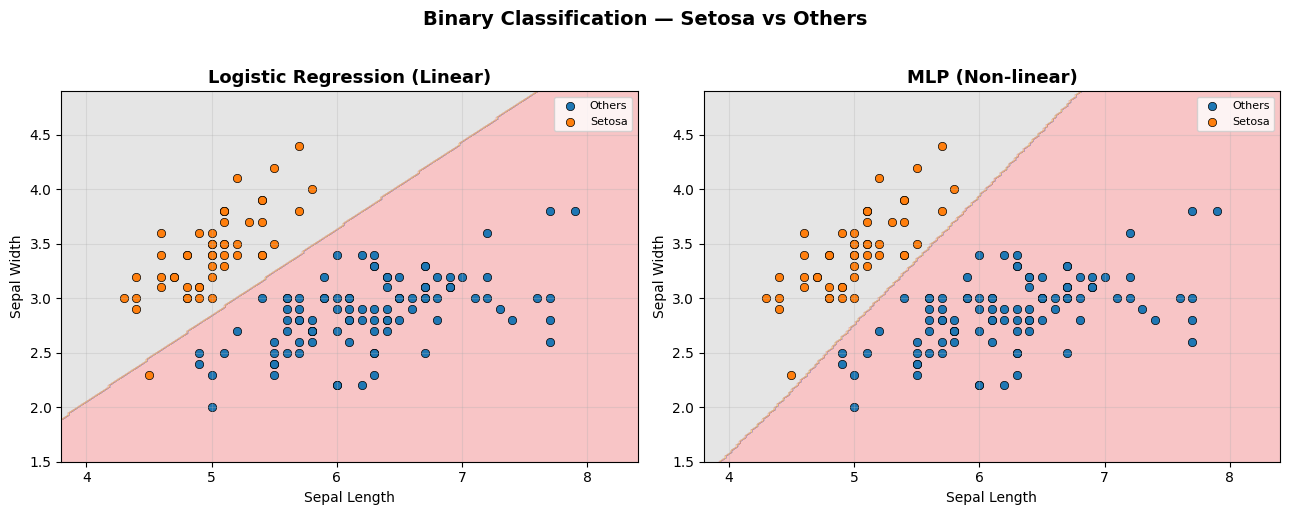


Binary Classification Results
Model                 Train Acc   Test Acc
------------------------------------------
Logistic                 0.9905     1.0000
MLP                      1.0000     1.0000


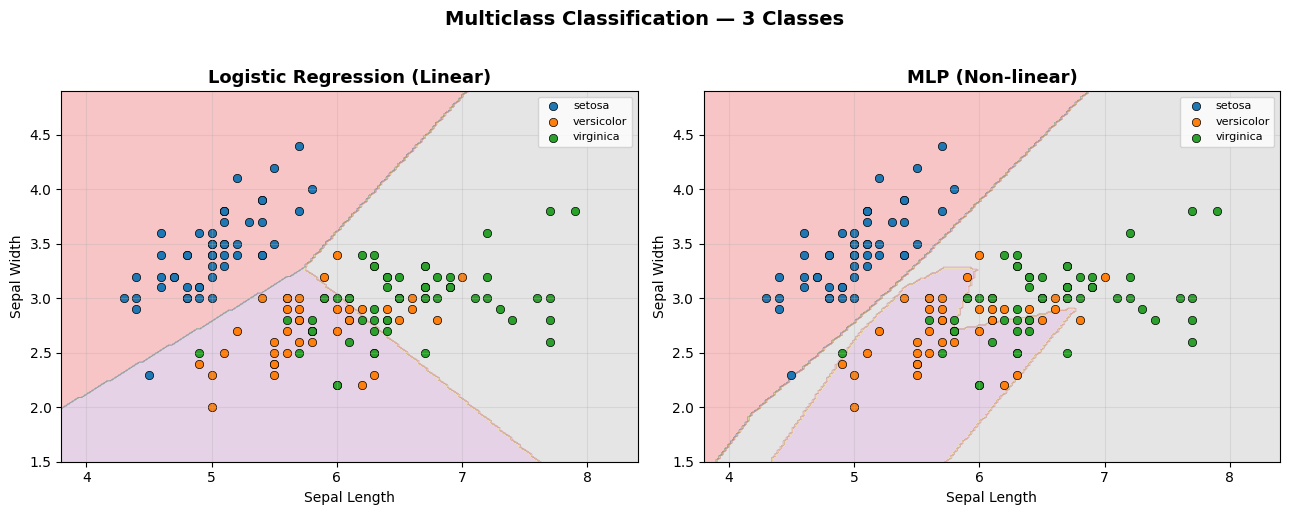


Multiclass Classification Results
Model                 Train Acc   Test Acc
------------------------------------------
Logistic                 0.7905     0.8222
MLP                      0.8095     0.7333


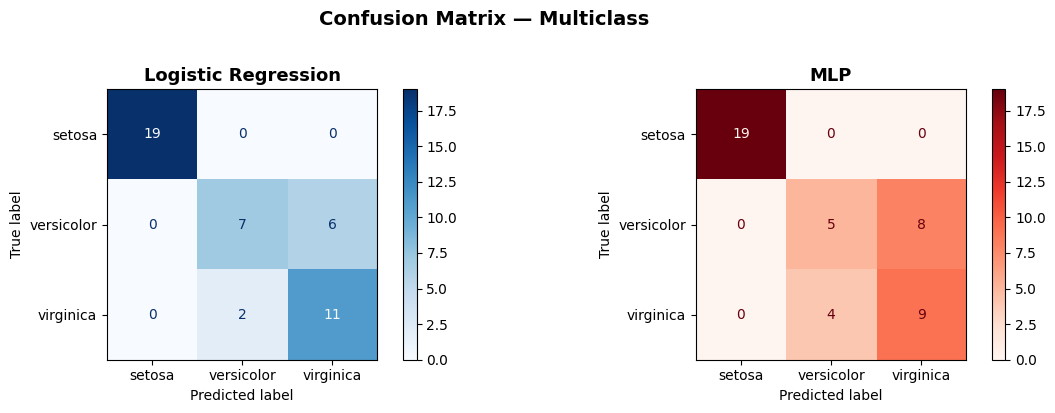

In [1]:
# ==============================
# Week 2 - IRIS Classification
# Linear vs Non-linear Decision Boundary
# ==============================
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ==============================
# 1. Load & Visualize
# ==============================
iris = datasets.load_iris()
X = iris.data[:, :2]   # first 2 features only (for 2D visualization)
y = iris.target
names = iris.target_names

print(f"Features: {X.shape}, Labels: {y.shape}")
print(f"Classes: {names}")

plt.figure(figsize=(6, 4))
for i, name in enumerate(names):
    plt.scatter(X[y==i, 0], X[y==i, 1], label=name, edgecolors='k', linewidth=0.5)
plt.xlabel('Sepal Length'); plt.ylabel('Sepal Width')
plt.title('IRIS Dataset (First Two Features)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ==============================
# 2. Decision Boundary Function
# ==============================
def plot_boundary(ax, model, X, y, title, class_names=None):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='Set1')
    labels = class_names if class_names is not None else [str(i) for i in np.unique(y)]
    for i, name in enumerate(labels):
        ax.scatter(X[y==i, 0], X[y==i, 1], label=name, edgecolors='k', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Sepal Length'); ax.set_ylabel('Sepal Width')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ==============================
# 3. Binary Classification (Setosa vs Others)
# ==============================
y_bin = (y == 0).astype(int)
bin_names = ['Others', 'Setosa']
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.3, random_state=42)

# Logistic Regression
log_model = make_pipeline(StandardScaler(), LogisticRegression())
log_model.fit(X_train, y_train)

# MLP Binary
mlp_bin = make_pipeline(StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(10,), solver='lbfgs', max_iter=2000, random_state=42))
mlp_bin.fit(X_train, y_train)

# --- Decision Boundary: Logistic vs MLP (side by side) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_boundary(ax1, log_model, X, y_bin, 'Logistic Regression (Linear)', bin_names)
plot_boundary(ax2, mlp_bin, X, y_bin, 'MLP (Non-linear)', bin_names)
fig.suptitle('Binary Classification — Setosa vs Others', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# --- Accuracy ---
print("\n" + "=" * 50)
print("Binary Classification Results")
print("=" * 50)
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 42)
print(f"{'Logistic':<20} {accuracy_score(y_train, log_model.predict(X_train)):>10.4f} {accuracy_score(y_test, log_model.predict(X_test)):>10.4f}")
print(f"{'MLP':<20} {accuracy_score(y_train, mlp_bin.predict(X_train)):>10.4f} {accuracy_score(y_test, mlp_bin.predict(X_test)):>10.4f}")

# ==============================
# 4. Multiclass Classification
# ==============================
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Multiclass
log_multi = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
log_multi.fit(X_train_mc, y_train_mc)

# MLP Multiclass
mlp_multi = make_pipeline(StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(10,), solver='lbfgs', max_iter=2000, random_state=42))
mlp_multi.fit(X_train_mc, y_train_mc)

# --- Decision Boundary: Logistic vs MLP (side by side) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_boundary(ax1, log_multi, X, y, 'Logistic Regression (Linear)', names)
plot_boundary(ax2, mlp_multi, X, y, 'MLP (Non-linear)', names)
fig.suptitle('Multiclass Classification — 3 Classes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# --- Accuracy ---
print("\n" + "=" * 50)
print("Multiclass Classification Results")
print("=" * 50)
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 42)
print(f"{'Logistic':<20} {accuracy_score(y_train_mc, log_multi.predict(X_train_mc)):>10.4f} {accuracy_score(y_test_mc, log_multi.predict(X_test_mc)):>10.4f}")
print(f"{'MLP':<20} {accuracy_score(y_train_mc, mlp_multi.predict(X_train_mc)):>10.4f} {accuracy_score(y_test_mc, mlp_multi.predict(X_test_mc)):>10.4f}")

# ==============================
# 5. Confusion Matrix (Multiclass MLP)
# ==============================
y_pred_mc = mlp_multi.predict(X_test_mc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test_mc, log_multi.predict(X_test_mc),
    display_labels=names, cmap='Blues', ax=ax1)
ax1.set_title('Logistic Regression', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_test_mc, y_pred_mc,
    display_labels=names, cmap='Reds', ax=ax2)
ax2.set_title('MLP', fontsize=13, fontweight='bold')

fig.suptitle('Confusion Matrix — Multiclass', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()